In [2]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
import pandas as pd
from sklearn.covariance import LedoitWolf

**DATA GENERATION**

In [3]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
data = data.dropna() # drop rows with missing values
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
y_test = x_test.pct_change().dropna() # predict next-day returns

x_train = data[data.index < "2023-01-01"] # train on past data
y_train = x_train.pct_change().dropna()

# Test prints
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training returns shape:", y_train.shape)
print("Test returns shape:", y_test.shape)

print("Training data head:")
print(x_train.head())
print("Training returns head:")
print(y_train.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

Training data shape: (1259, 10)
Test data shape: (826, 10)
Training returns shape: (1258, 10)
Test returns shape: (825, 10)
Training data head:
Ticker           AAPL    AMD       AMZN       GOOG         IBM       INTC  \
Date                                                                        
2018-01-02  40.304173  10.98  59.450500  52.816387  103.412842  39.330376   
2018-01-03  40.297146  11.55  60.209999  53.683262  106.255424  37.995579   
2018-01-04  40.484337  12.12  60.479500  53.877670  108.407463  37.298801   
2018-01-05  40.945267  11.88  61.457001  54.662724  108.937119  37.559048   
2018-01-08  40.793182  12.28  62.343498  54.896301  109.594116  37.559048   

Ticker            META       MSFT      NVDA       TSLA  
Date                                                    
2018-01-02  180.007401  78.870346  4.928266  21.368668  
2018-01-03  183.232071  79.237419  5.252614  21.150000  
2018-01-04  182.894730  79.934807  5.280304  20.974667  
2018-01-05  185.395111  80.9258

In [4]:
x_test_tensor = torch.tensor(x_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

x_train_tensor = torch.tensor(x_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Test prints
print("Aligned training data shape:", x_train_tensor.shape)
print("Aligned test data shape:", x_test_tensor.shape)
print("Aligned training returns shape:", y_train_tensor.shape)
print("Aligned test returns shape:", y_test_tensor.shape)

print("Aligned training data head:")
print(x_train_tensor[:5])
print("Aligned training returns head:")
print(y_train_tensor[:5])

Aligned training data shape: torch.Size([1258, 10])
Aligned test data shape: torch.Size([825, 10])
Aligned training returns shape: torch.Size([1258, 10])
Aligned test returns shape: torch.Size([825, 10])
Aligned training data head:
tensor([[ 40.3042,  10.9800,  59.4505,  52.8164, 103.4128,  39.3304, 180.0074,
          78.8703,   4.9283,  21.3687],
        [ 40.2971,  11.5500,  60.2100,  53.6833, 106.2554,  37.9956, 183.2321,
          79.2374,   5.2526,  21.1500],
        [ 40.4843,  12.1200,  60.4795,  53.8777, 108.4075,  37.2988, 182.8947,
          79.9348,   5.2803,  20.9747],
        [ 40.9453,  11.8800,  61.4570,  54.6627, 108.9371,  37.5590, 185.3951,
          80.9258,   5.3250,  21.1053],
        [ 40.7932,  12.2800,  62.3435,  54.8963, 109.5941,  37.5590, 186.8140,
          81.0085,   5.4882,  22.4273]])
Aligned training returns head:
tensor([[-0.0002,  0.0519,  0.0128,  0.0164,  0.0275, -0.0339,  0.0179,  0.0047,
          0.0658, -0.0102],
        [ 0.0046,  0.0494,  0.00

In [5]:
# prepare multi features
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std

build_feature_panel(data, lag_days=5, ma_windows=(5, 10), vol_windows=(5,))

# build multi-feature panel and split into train/test
X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, _ = \
    train_test_split_panel(data, split_date="2023-01-01")

X_train_std, X_test_std, _, _ = standardize_panel(X_train, X_test)

x_train_tensor_mf = torch.tensor(X_train_std, dtype=torch.float32)  # (B, F, N)
x_test_tensor_mf  = torch.tensor(X_test_std,  dtype=torch.float32)
y_train_tensor_mf = torch.tensor(Y_train, dtype=torch.float32)  # (B, N)
y_test_tensor_mf  = torch.tensor(Y_test,  dtype=torch.float32)

print("Multi-feature train shape:", x_train_tensor_mf.shape)
print("Multi-feature test shape:", x_test_tensor_mf.shape)
print("Multi-feature train target shape:", y_train_tensor_mf.shape)
print("Multi-feature test target shape:", y_test_tensor_mf.shape)

feature_sets = {
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

Multi-feature train shape: torch.Size([1249, 10, 10])
Multi-feature test shape: torch.Size([825, 10, 10])
Multi-feature train target shape: torch.Size([1249, 10])
Multi-feature test target shape: torch.Size([825, 10])


**GRAPH CONSTRUCTION**

In [6]:
def stock_graph(y):
    # correlation matrix as adjacency (as a start)
    corr = np.corrcoef(y.T)
    np.fill_diagonal(corr, 0)  # remove self-loops
    return corr

def normalize_graph(G):
    # optional: divide by largest eigenvalue
    eigs = np.linalg.eigvals(G)
    return G / np.max(np.abs(eigs))

# some other options

def partial_corr_graph(returns):
    lw = LedoitWolf().fit(returns)
    prec = lw.precision_  # inverse covariance
    # normalize to partial correlations
    d = np.sqrt(np.diag(prec))
    partial = -prec / np.outer(d, d)
    np.fill_diagonal(partial, 0)
    return partial

def threshold_graph(corr, threshold=0.5):
    G = corr.numpy().copy()
    G[np.abs(G) < threshold] = 0
    np.fill_diagonal(G, 0)
    return G

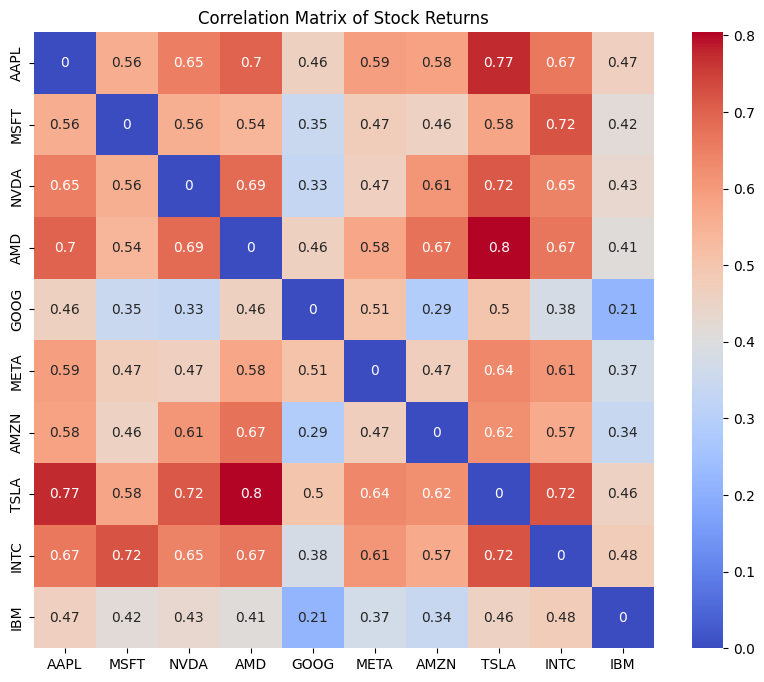

In [7]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

**Graph Filter**

In [8]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

**Graph Perceptron**

In [9]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y  

**Multi-layer GNN**

In [10]:
class MLGNN(nn.Module):
    def __init__(self, gso, l, k, sigma):
        super().__init__()
        layers = []
        for layer in range(l):
            if layer < l - 1:
                layers.append(graph_perceptron(gso, k[layer], sigma))
            else:
                layers.append(graph_perceptron(gso, k[layer], nn.Identity()))  # no activation on last layer
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y = self.layers(x)
        return y

**Multiple Feature Filters and GNNs**

In [11]:
def FilterFunctionMulti(h, S, x):
    
    # we assume that the input x PyTorch tensor [B, G, N]
    # the output is y PyTorch tensor [B, F, N]
    # Number of output features
    F = h.shape[0]
    
    # Number of filter taps
    K = h.shape[1]
    
    # Number of input features
    G = h.shape[2]
    
    # Number of nodes
    N = S.shape[1]
    
    # Batch size
    B = x.shape[0]

    # Create concatenation dimension and initialize concatenation tensor z
    x = x.reshape([B, 1, G, N])
    S = S.reshape([1, N, N])
    z = x
    
    # Loop over the number of filter taps
    for k in range(1, K):
        
        # S*x
        x = torch.matmul(x, S)
        
        # Reshape
        xS = x.reshape([B, 1, G, N])
        
        # Concatenate
        z = torch.cat((z, xS), dim=1)
    
    # Multiply by h
    y = torch.matmul(z.permute(0, 3, 1, 2).reshape([B, N, K*G]), 
                     h.reshape([F, K*G]).permute(1, 0)).permute(0, 2, 1)
    return y
    
    
class GraphFilterMulti(nn.Module):
    def __init__(self, gso, k, f_in, f_out):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.f_in = f_in
        self.f_out = f_out
        self.weight = nn.Parameter(torch.randn(self.f_out, self.k, self.f_in))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.f_in * self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return FilterFunctionMulti(self.weight, self.gso, x)

In [12]:
class GNNMulti(nn.Module):
    def __init__(self, gso, l, k, f, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.l = l
        self.k = k
        self.f = f
        self.sigma = sigma
        
        gml = []
        for layer in range(l):
            gml.append(GraphFilterMulti(gso, k[layer], f[layer], f[layer+1]))
            if layer < l - 1:  # no activation after last layer
                gml.append(sigma)
        
        self.gml = nn.Sequential(*gml)
        
    def forward(self, x):
        return self.gml(x)

**TESTING**

In [13]:
def train_model(model, x_train, y_train, lr=0.01, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1} with loss {loss.item():.6f}")
            break
    return model, losses

In [14]:
def train_model_multi(model, x_train, y_train, lr=0.001, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train).squeeze(1)  # (B, 1, N) --> (B, N)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1}")
            break
    return model, losses

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/2249465692.py:10: RuntimeWarning: invalid value encountered in divide
  return G / np.max(np.abs(eigs))
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/3586927298.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


Training Graph Filter...
Epoch 10/300, Loss: 0.196947
Epoch 20/300, Loss: 0.055263
Epoch 30/300, Loss: 0.013776
Epoch 40/300, Loss: 0.012160
Epoch 50/300, Loss: 0.011524
Epoch 60/300, Loss: 0.008143
Epoch 70/300, Loss: 0.006115
Epoch 80/300, Loss: 0.005049
Epoch 90/300, Loss: 0.004061
Epoch 100/300, Loss: 0.003238
Epoch 110/300, Loss: 0.002618
Epoch 120/300, Loss: 0.002131
Epoch 130/300, Loss: 0.001759
Epoch 140/300, Loss: 0.001482
Epoch 150/300, Loss: 0.001278
Epoch 160/300, Loss: 0.001132
Epoch 170/300, Loss: 0.001029
Epoch 180/300, Loss: 0.000958
Epoch 190/300, Loss: 0.000910
Epoch 200/300, Loss: 0.000877
Epoch 210/300, Loss: 0.000856
Epoch 220/300, Loss: 0.000843
Epoch 230/300, Loss: 0.000834
Epoch 240/300, Loss: 0.000829
Epoch 250/300, Loss: 0.000825
Epoch 260/300, Loss: 0.000823
Epoch 270/300, Loss: 0.000822
Epoch 280/300, Loss: 0.000822
Epoch 290/300, Loss: 0.000821
Epoch 300/300, Loss: 0.000821


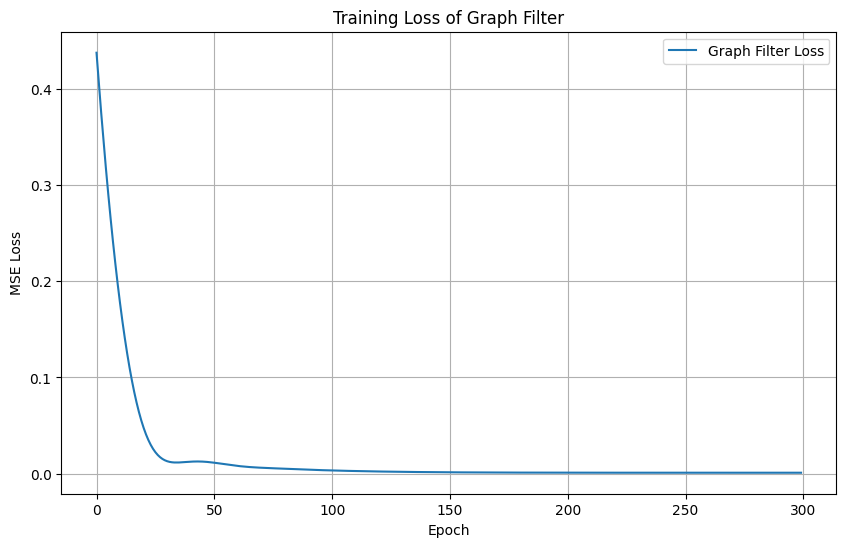

Training Graph Perceptron...
Epoch 10/300, Loss: 0.001148
Epoch 20/300, Loss: 0.002605
Epoch 30/300, Loss: 0.000883
Epoch 40/300, Loss: 0.000943
Epoch 50/300, Loss: 0.000818
Epoch 60/300, Loss: 0.000767
Epoch 70/300, Loss: 0.000774
Epoch 80/300, Loss: 0.000767
Epoch 90/300, Loss: 0.000765
Epoch 100/300, Loss: 0.000765
Epoch 110/300, Loss: 0.000765
Epoch 120/300, Loss: 0.000764
Epoch 130/300, Loss: 0.000764
Epoch 140/300, Loss: 0.000764
Epoch 150/300, Loss: 0.000764
Epoch 160/300, Loss: 0.000764
Epoch 170/300, Loss: 0.000764
Epoch 180/300, Loss: 0.000764
Epoch 190/300, Loss: 0.000764
Epoch 200/300, Loss: 0.000764
Epoch 210/300, Loss: 0.000764
Epoch 220/300, Loss: 0.000764
Epoch 230/300, Loss: 0.000764
Epoch 240/300, Loss: 0.000764
Epoch 250/300, Loss: 0.000763
Epoch 260/300, Loss: 0.000763
Epoch 270/300, Loss: 0.000763
Epoch 280/300, Loss: 0.000763
Epoch 290/300, Loss: 0.000763
Epoch 300/300, Loss: 0.000763


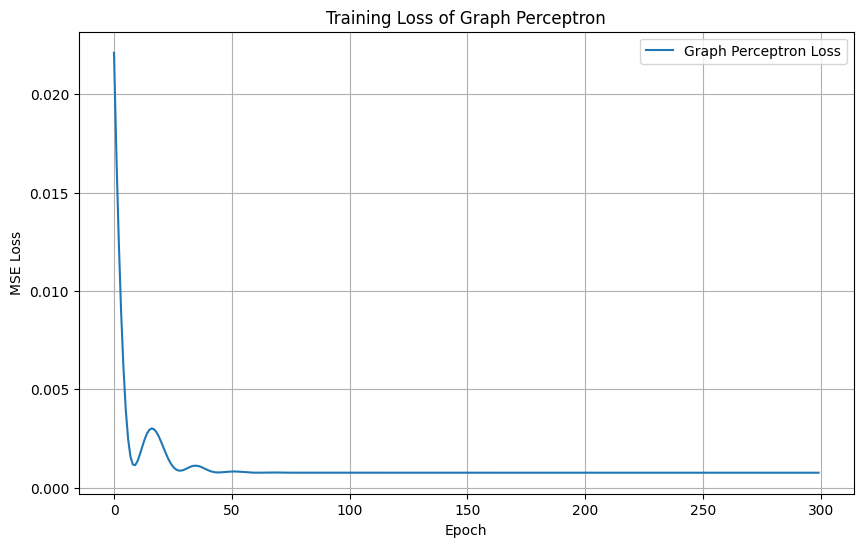

Training MLGNN...
Epoch 10/300, Loss: 0.000919
Epoch 20/300, Loss: 0.000903
Epoch 30/300, Loss: 0.000874
Epoch 40/300, Loss: 0.000793
Epoch 50/300, Loss: 0.000760
Epoch 60/300, Loss: 0.000749
Epoch 70/300, Loss: 0.000745
Epoch 80/300, Loss: 0.000744
Epoch 90/300, Loss: 0.000743
Epoch 100/300, Loss: 0.000742
Epoch 110/300, Loss: 0.000742
Epoch 120/300, Loss: 0.000742
Epoch 130/300, Loss: 0.000742
Epoch 140/300, Loss: 0.000741
Epoch 150/300, Loss: 0.000741
Epoch 160/300, Loss: 0.000741
Epoch 170/300, Loss: 0.000741
Epoch 180/300, Loss: 0.000741
Epoch 190/300, Loss: 0.000741
Epoch 200/300, Loss: 0.000741
Epoch 210/300, Loss: 0.000740
Epoch 220/300, Loss: 0.000740
Epoch 230/300, Loss: 0.000740
Epoch 240/300, Loss: 0.000740
Epoch 250/300, Loss: 0.000740
Epoch 260/300, Loss: 0.000740
Epoch 270/300, Loss: 0.000740
Epoch 280/300, Loss: 0.000740
Epoch 290/300, Loss: 0.000740
Epoch 300/300, Loss: 0.000740


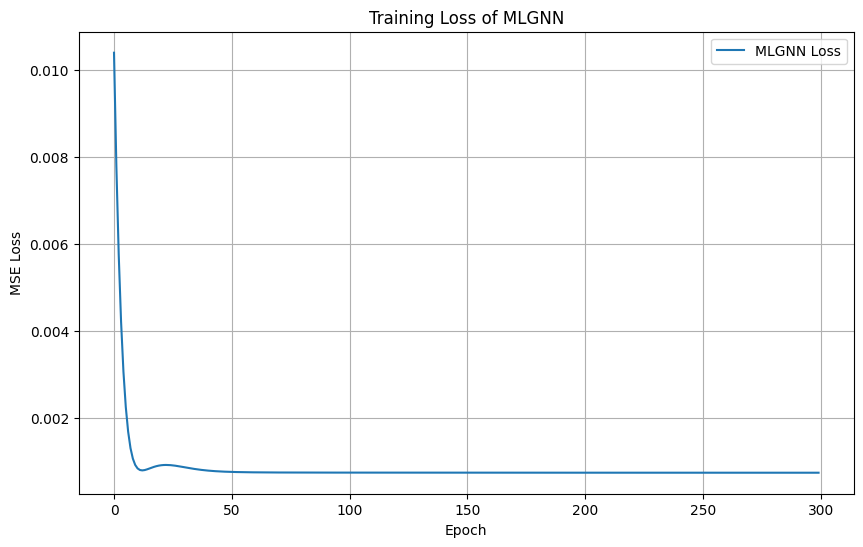

Training Multi Feature Filter...
Epoch 10/300, Loss: 0.261219
Epoch 20/300, Loss: 0.174778
Epoch 30/300, Loss: 0.116454
Epoch 40/300, Loss: 0.080747
Epoch 50/300, Loss: 0.060204
Epoch 60/300, Loss: 0.048315
Epoch 70/300, Loss: 0.040777
Epoch 80/300, Loss: 0.035312
Epoch 90/300, Loss: 0.030941
Epoch 100/300, Loss: 0.027285
Epoch 110/300, Loss: 0.024177
Epoch 120/300, Loss: 0.021508
Epoch 130/300, Loss: 0.019191
Epoch 140/300, Loss: 0.017159
Epoch 150/300, Loss: 0.015365
Epoch 160/300, Loss: 0.013771
Epoch 170/300, Loss: 0.012352
Epoch 180/300, Loss: 0.011087
Epoch 190/300, Loss: 0.009958
Epoch 200/300, Loss: 0.008951
Epoch 210/300, Loss: 0.008054
Epoch 220/300, Loss: 0.007255
Epoch 230/300, Loss: 0.006546
Epoch 240/300, Loss: 0.005915
Epoch 250/300, Loss: 0.005357
Epoch 260/300, Loss: 0.004862
Epoch 270/300, Loss: 0.004425
Epoch 280/300, Loss: 0.004038
Epoch 290/300, Loss: 0.003696
Epoch 300/300, Loss: 0.003395


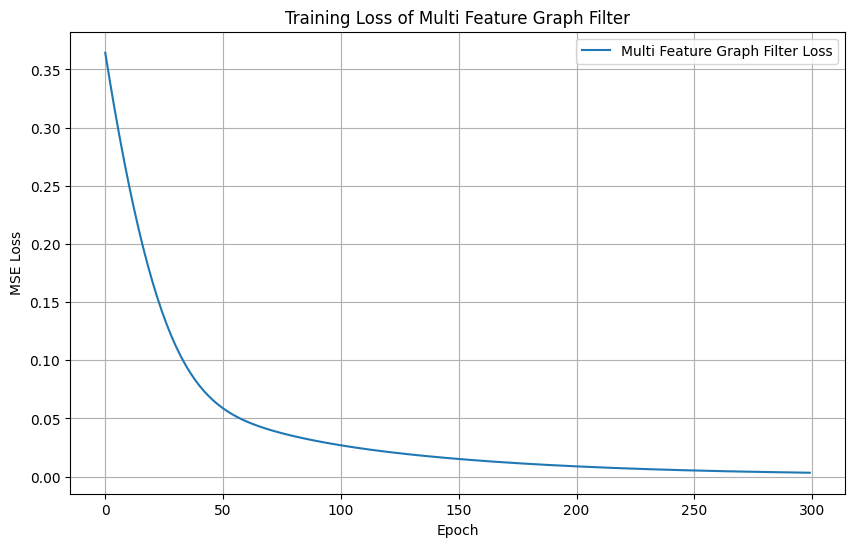

Training Multi Feature GNN...
Epoch 10/300, Loss: 0.005962
Epoch 20/300, Loss: 0.003023
Epoch 30/300, Loss: 0.001910
Epoch 40/300, Loss: 0.001437
Epoch 50/300, Loss: 0.001257
Epoch 60/300, Loss: 0.001131
Epoch 70/300, Loss: 0.001054
Epoch 80/300, Loss: 0.001001
Epoch 90/300, Loss: 0.000961
Epoch 100/300, Loss: 0.000931
Epoch 110/300, Loss: 0.000907
Epoch 120/300, Loss: 0.000888
Epoch 130/300, Loss: 0.000872
Epoch 140/300, Loss: 0.000858
Epoch 150/300, Loss: 0.000845
Epoch 160/300, Loss: 0.000834
Epoch 170/300, Loss: 0.000823
Epoch 180/300, Loss: 0.000814
Epoch 190/300, Loss: 0.000805
Epoch 200/300, Loss: 0.000797
Epoch 210/300, Loss: 0.000790
Epoch 220/300, Loss: 0.000783
Epoch 230/300, Loss: 0.000777
Epoch 240/300, Loss: 0.000772
Epoch 250/300, Loss: 0.000767
Epoch 260/300, Loss: 0.000762
Epoch 270/300, Loss: 0.000757
Epoch 280/300, Loss: 0.000753
Epoch 290/300, Loss: 0.000748
Epoch 300/300, Loss: 0.000745


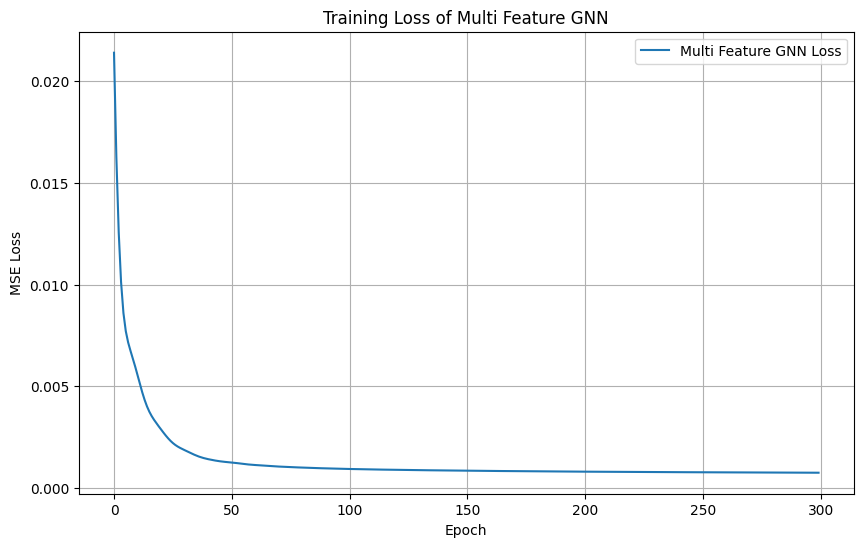

In [15]:
corr = stock_graph(y_train)
corr = normalize_graph(corr)
corr = torch.tensor(corr, dtype=torch.float32)

# alternative graph constructions
partial_corr = partial_corr_graph(y_train)
partial_corr = normalize_graph(partial_corr)
partial_corr = torch.tensor(partial_corr, dtype=torch.float32)

thresholded_corr = threshold_graph(corr, threshold=0.5)
thresholded_corr = normalize_graph(thresholded_corr)
thresholded_corr = torch.tensor(thresholded_corr, dtype=torch.float32)

# compute statistics from training data!
x_mean = x_train_tensor.mean(dim=0)
x_std  = x_train_tensor.std(dim=0) + 1e-8

x_train_tensor_norm = (x_train_tensor - x_mean) / x_std
x_test_tensor_norm  = (x_test_tensor  - x_mean) / x_std

x_muli_feature_train = x_train_tensor_norm.unsqueeze(1) # shape [B, 1, N]
x_muli_feature_test = x_test_tensor_norm.unsqueeze(1) # shape [B, 1, N]

K = 3
gf_model = graph_filter(corr, K)
gp_model = graph_perceptron(corr, K, nn.ReLU())
mlgnn_model = MLGNN(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU())
mfgf_model = GraphFilterMulti(corr, k=3, f_in=10, f_out=1)
mfgnn_model = GNNMulti(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

mfgnn_model_partial = GNNMulti(thresholded_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])
mfgnn_model_thresholded = GNNMulti(thresholded_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

print("Training Graph Filter...")
gf_model, gf_losses = train_model(gf_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph filter
plt.figure(figsize=(10, 6))
plt.plot(gf_losses, label='Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Filter')
plt.legend()
plt.grid()
plt.show()

print("Training Graph Perceptron...")
gp_model, gp_losses = train_model(gp_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph perceptron
plt.figure(figsize=(10, 6))
plt.plot(gp_losses, label='Graph Perceptron Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Perceptron')
plt.legend()
plt.grid()
plt.show()

print("Training MLGNN...")
mlgnn_model, mlgnn_losses = train_model(mlgnn_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for MLGNN
plt.figure(figsize=(10, 6))
plt.plot(mlgnn_losses, label='MLGNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of MLGNN')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature Filter...")
mfgf_model, mfgf_losses = train_model_multi(mfgf_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature graph filter
plt.figure(figsize=(10, 6))
plt.plot(mfgf_losses, label='Multi Feature Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature Graph Filter')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature GNN...")
mfgnn_model, mfgnn_losses = train_model_multi(mfgnn_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_losses, label='Multi Feature GNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN')
plt.legend()
plt.grid()
plt.show()

# print("Training Multi Feature GNN with Partial Correlation Graph...")
# mfgnn_model_partial, mfgnn_partial_losses = train_model_multi(mfgnn_model_partial, x_train_tensor_mf, y_train_tensor_mf)
# # plot loss per epoch for multi feature GNN with partial correlation graph
# plt.figure(figsize=(10, 6))
# plt.plot(mfgnn_partial_losses, label='Multi Feature GNN with Partial Correlation Graph Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Training Loss of Multi Feature GNN with Partial Correlation Graph')
# plt.legend()
# plt.grid()
# plt.show()  

# print("Training Multi Feature GNN with Thresholded Correlation Graph...")
# mfgnn_model_thresholded, mfgnn_thresholded_losses = train_model_multi(mfgnn_model_thresholded, x_train_tensor_mf, y_train_tensor_mf)
# # plot loss per epoch for multi feature GNN with thresholded correlation graph
# plt.figure(figsize=(10, 6))
# plt.plot(mfgnn_thresholded_losses, label='Multi Feature GNN with Thresholded Correlation Graph Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Training Loss of Multi Feature GNN with Thresholded Correlation Graph')
# plt.legend()
# plt.grid()
# plt.show()


=== Test Results ===
Graph Filter Test Loss: 6.131357
Graph Perceptron Test Loss: 1.107891
MLGNN Test Loss: 0.000749
Multi Feature Graph Filter Test Loss: 0.003834
Multi Feature GNN Test Loss: 0.000777


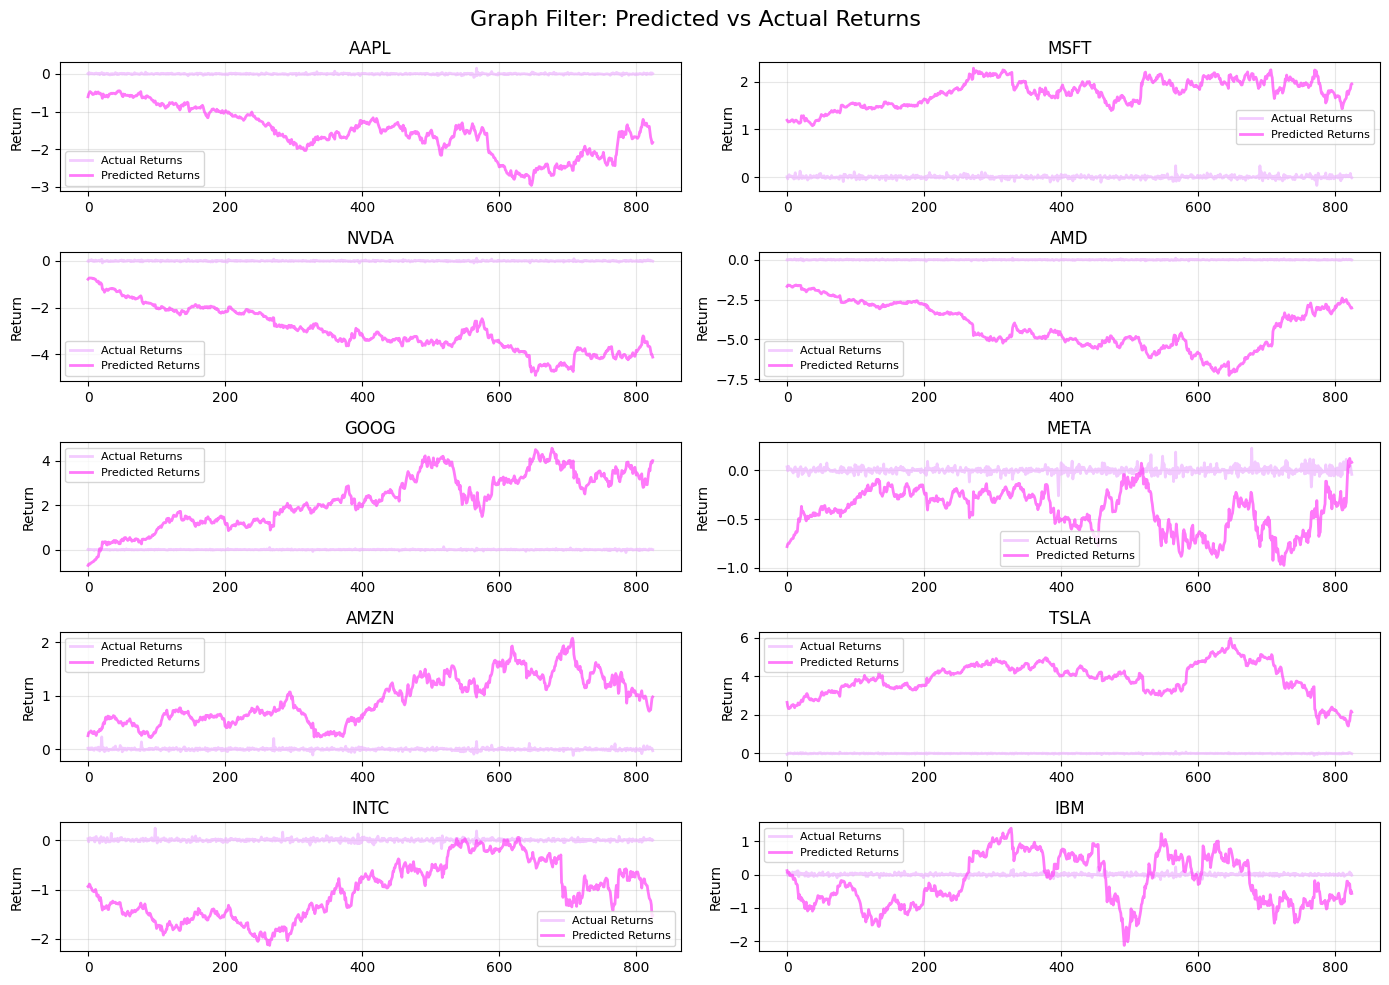

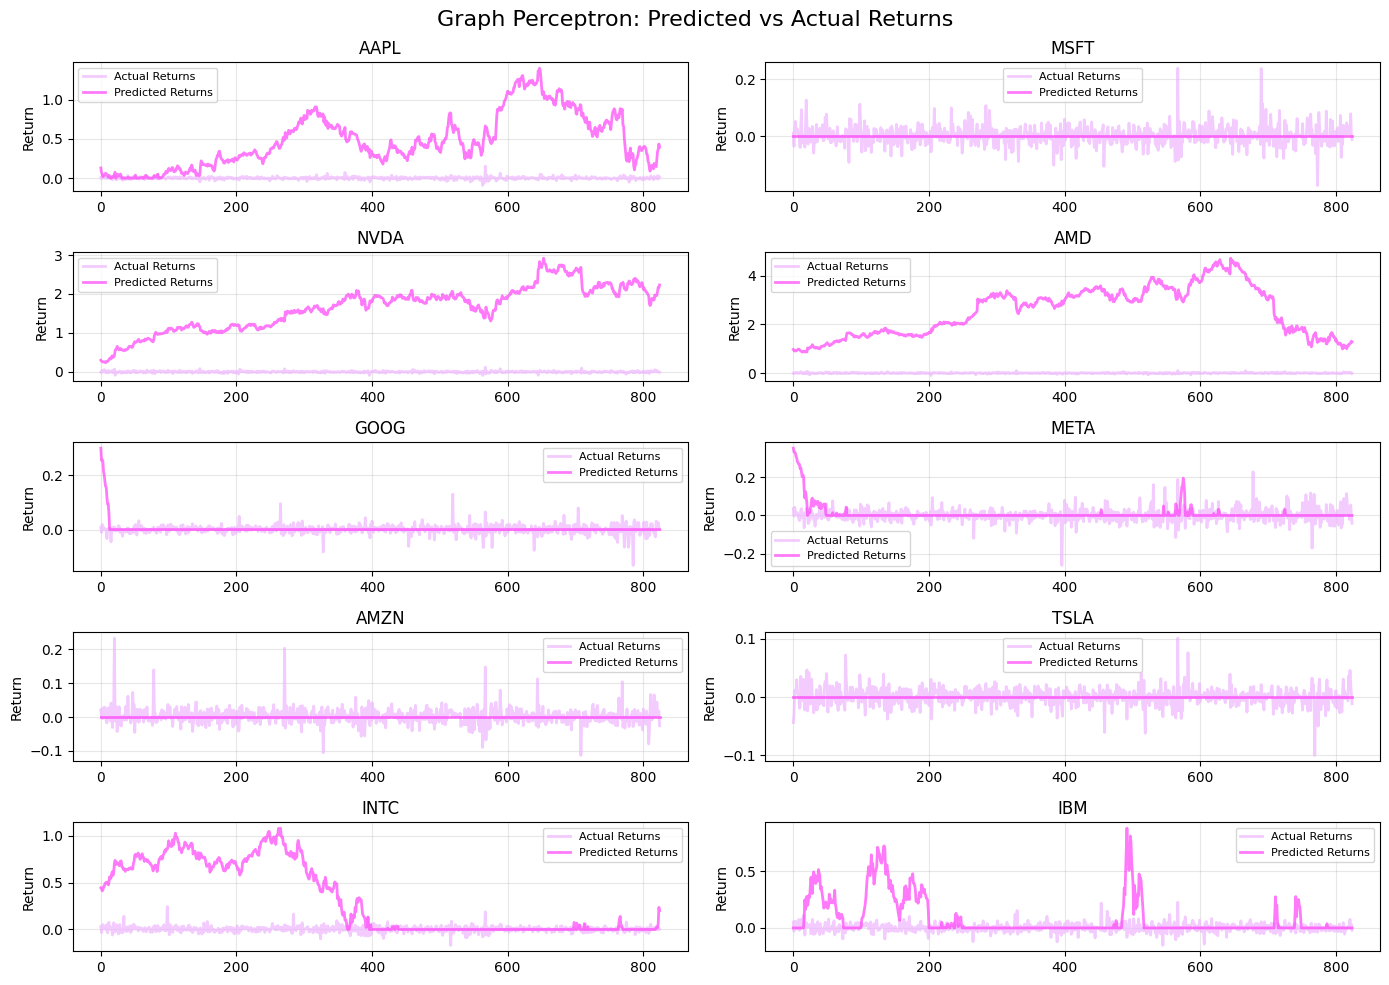

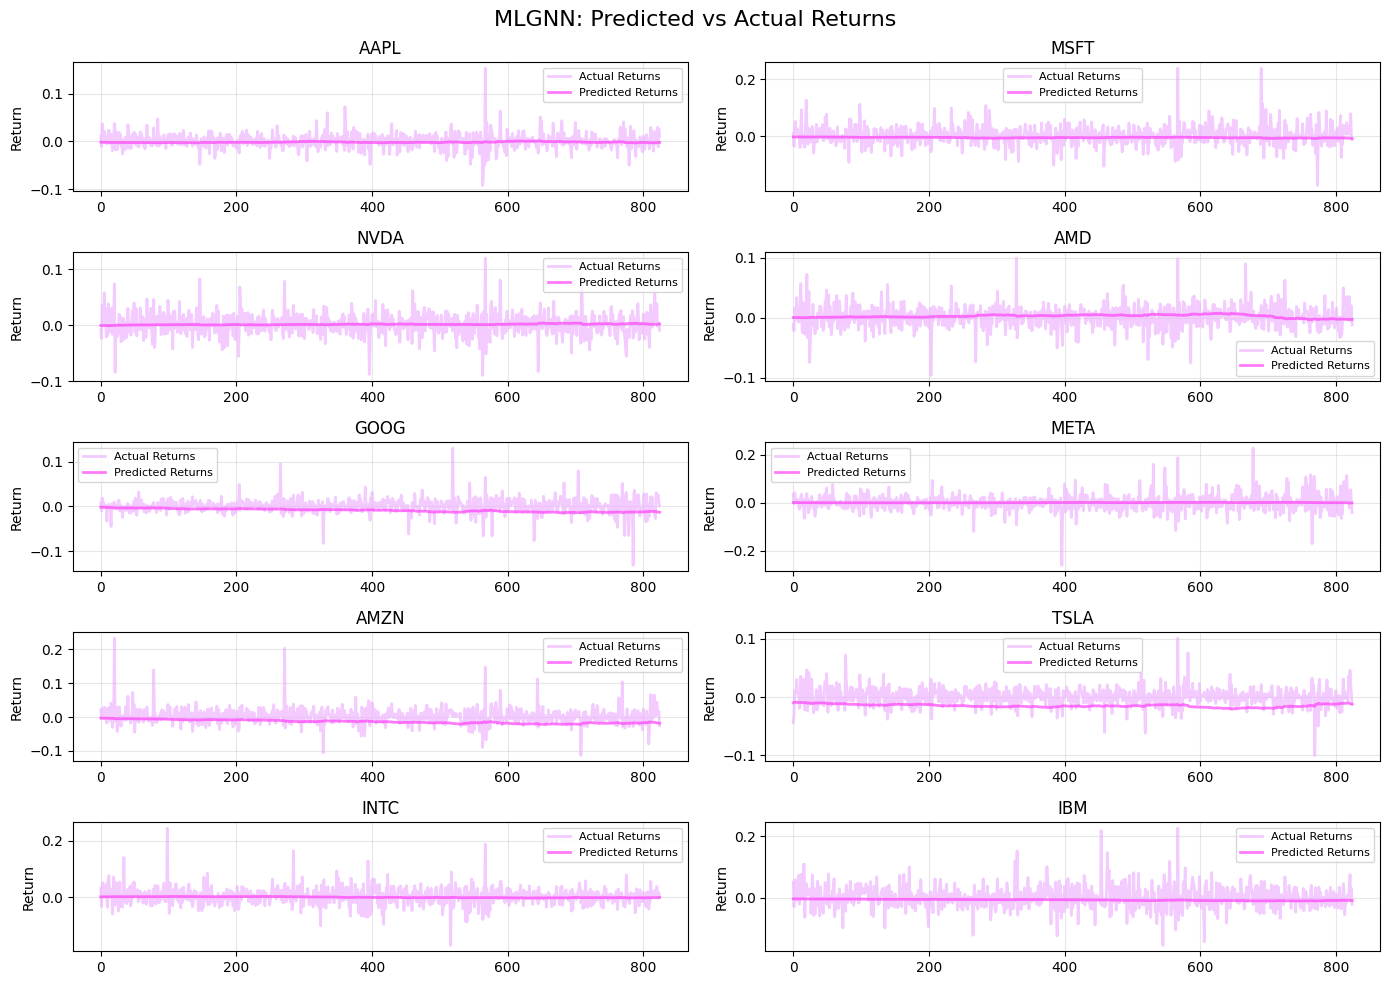

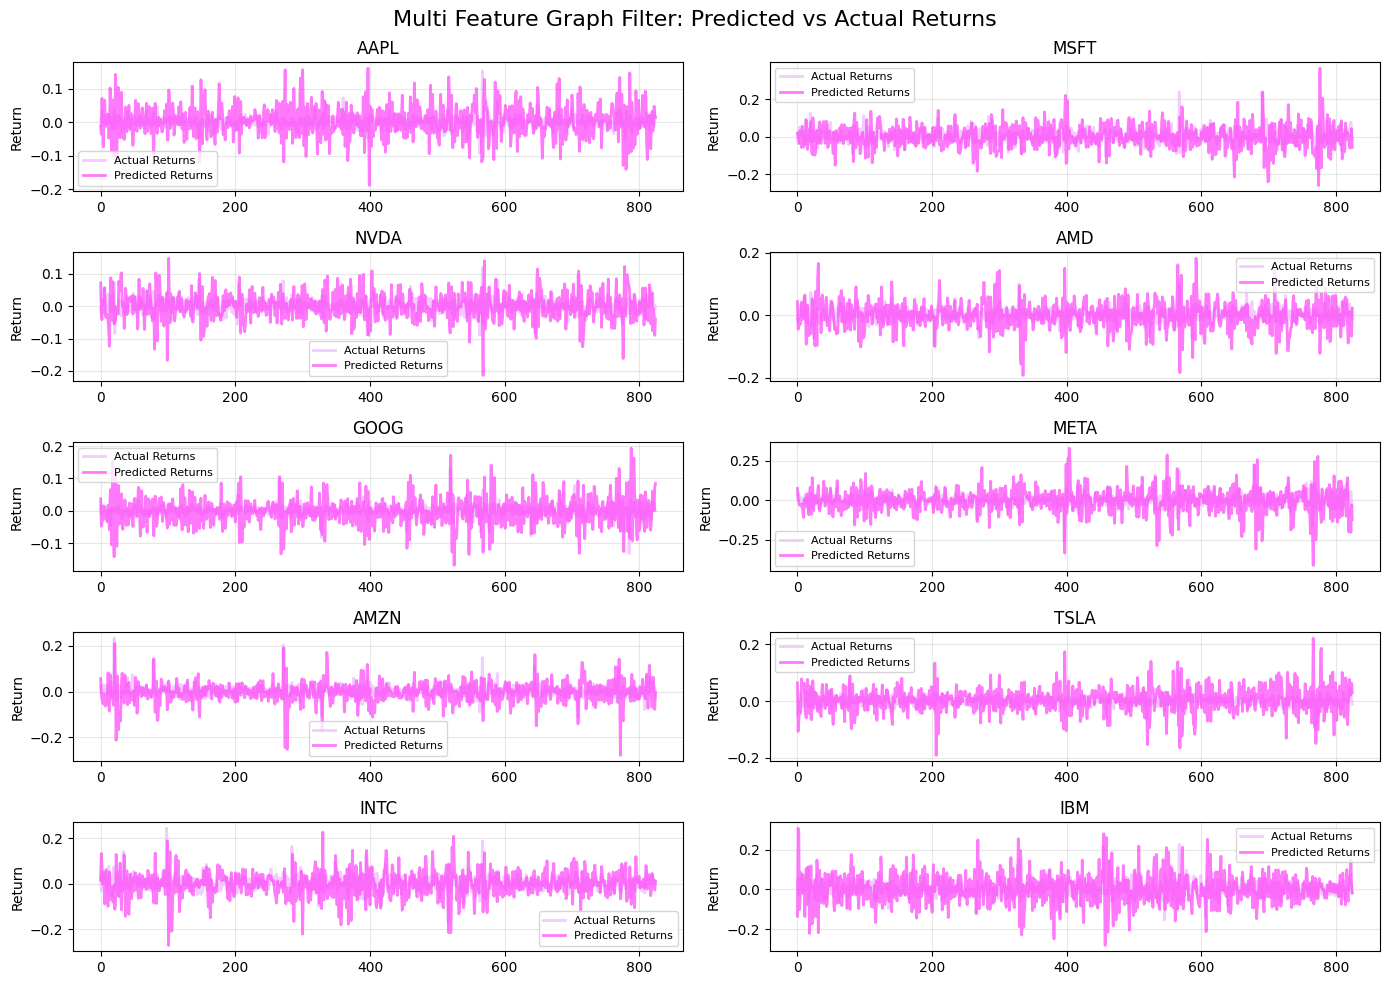

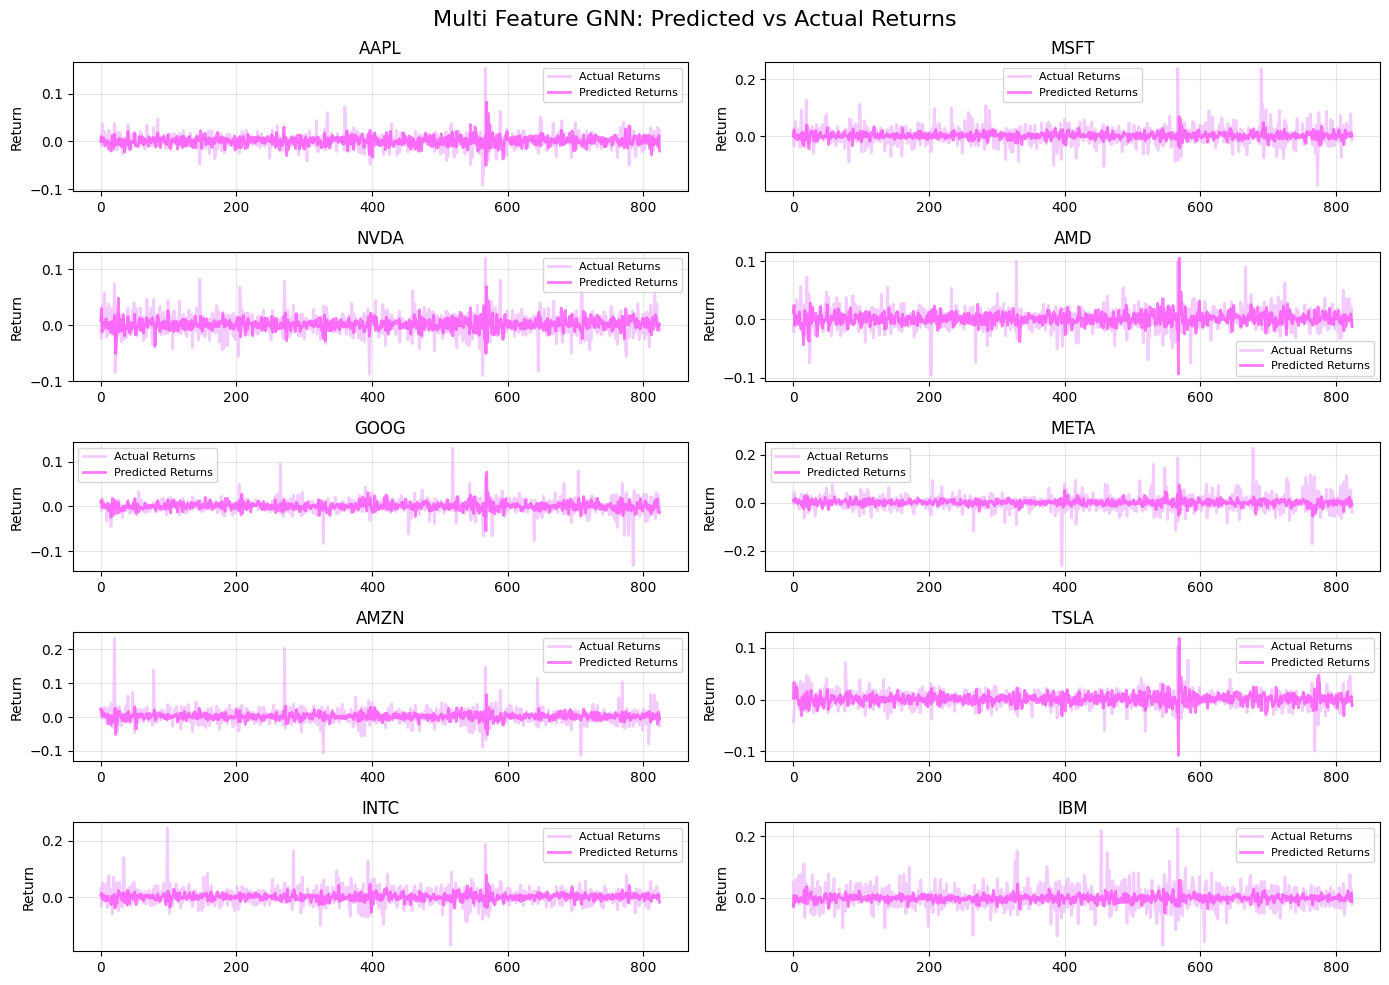

In [16]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

# Evaluate models on test data
criterion = nn.MSELoss()

# Make predictions with both models
with torch.no_grad():
    gf_pred = gf_model(x_test_tensor)
    gp_pred = gp_model(x_test_tensor)
    mlgnn_pred = mlgnn_model(x_test_tensor)
    mfgf_pred = mfgf_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    
    # Compute test loss
    gf_test_loss = criterion(gf_pred, y_test_tensor)
    gp_test_loss = criterion(gp_pred, y_test_tensor)
    mlgnn_test_loss = criterion(mlgnn_pred, y_test_tensor)
    mfgf_test_loss = criterion(mfgf_pred, y_test_tensor_mf)
    mfgnn_test_loss = criterion(mfgnn_pred, y_test_tensor_mf)

print(f"\n=== Test Results ===")
print(f"Graph Filter Test Loss: {gf_test_loss.item():.6f}")
print(f"Graph Perceptron Test Loss: {gp_test_loss.item():.6f}")
print(f"MLGNN Test Loss: {mlgnn_test_loss.item():.6f}")
print(f"Multi Feature Graph Filter Test Loss: {mfgf_test_loss.item():.6f}")
print(f"Multi Feature GNN Test Loss: {mfgnn_test_loss.item():.6f}")

# Plot predicted vs actual returns per stock for Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Graph Perceptron
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Perceptron: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gp_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for MLGNN
plt.figure(figsize=(14, 10))
plt.suptitle('MLGNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mlgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature GNN
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Model Evaluation**

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/2248705420.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]


           model      mse  median_mse  std_mse      mae
    Graph Filter 0.010375    0.001468 0.024123 0.066143
Graph Perceptron 0.002284    0.000291 0.005675 0.030430
           MLGNN 0.000680    0.000142 0.002485 0.017387
 MF Graph Filter 0.003834    0.001100 0.008440 0.044978
          MF GNN 0.000777    0.000188 0.002514 0.019232


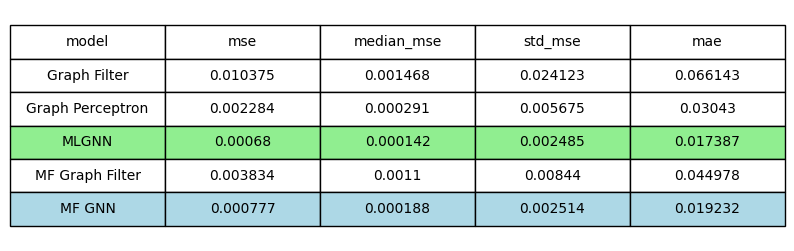

In [44]:
from scipy.stats import pearsonr
import dataframe_image as dfi

with torch.no_grad():
    gf_pred    = gf_model(x_test_tensor_norm)
    gp_pred    = gp_model(x_test_tensor_norm)
    mlgnn_pred = mlgnn_model(x_test_tensor_norm)
    mfgf_pred  = mfgf_model(x_test_tensor_mf).squeeze(1)
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1)


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    median_mse = np.median((y_true_np - y_pred_np) ** 2)
    std_mse = np.std((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    
    # correlation per stock, then average
    corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]
    avg_corr = np.mean(corrs)
    
    return {
        "mse": float(mse),
        "median_mse": float(median_mse),
        "std_mse": float(std_mse),
        "mae": float(mae)
    }

results = {
    "Graph Filter":       evaluate_metrics(y_test_tensor,  gf_pred),
    "Graph Perceptron":   evaluate_metrics(y_test_tensor,  gp_pred),
    "MLGNN":              evaluate_metrics(y_test_tensor,  mlgnn_pred),
    "MF Graph Filter":    evaluate_metrics(y_test_tensor_mf,   mfgf_pred),
    "MF GNN":             evaluate_metrics(y_test_tensor_mf,   mfgnn_pred),
}

summary = pd.DataFrame(results).T
summary.index.name = "model"
summary = summary.reset_index()
summary.columns = ["model", "mse", "median_mse", "std_mse", "mae"]
print(summary.to_string(index=False))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=summary.round(6).values,
    colLabels=summary.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# highlight best (min) value per numeric column in green
numeric_cols = ["mse", "median_mse", "std_mse", "mae"]

# highlight full MLGNN row (best overall)
mlgnn_row = summary[summary['model'] == 'MLGNN'].index[0]
for col_idx in range(len(summary.columns)):
    table[mlgnn_row + 1, col_idx].set_facecolor("lightgreen")

# highlight full MF GNN row
mfgnn_row = summary[summary['model'] == 'MF GNN'].index[0]
for col_idx in range(len(summary.columns)):
    table[mfgnn_row + 1, col_idx].set_facecolor("lightgreen")

# highlight MF GNN row
mfgnn_row = summary[summary['model'] == 'MF GNN'].index[0]
for col_idx in range(len(summary.columns)):
    table[mfgnn_row + 1, col_idx].set_facecolor("lightblue")

plt.savefig("results_table.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate best model with different feature sets



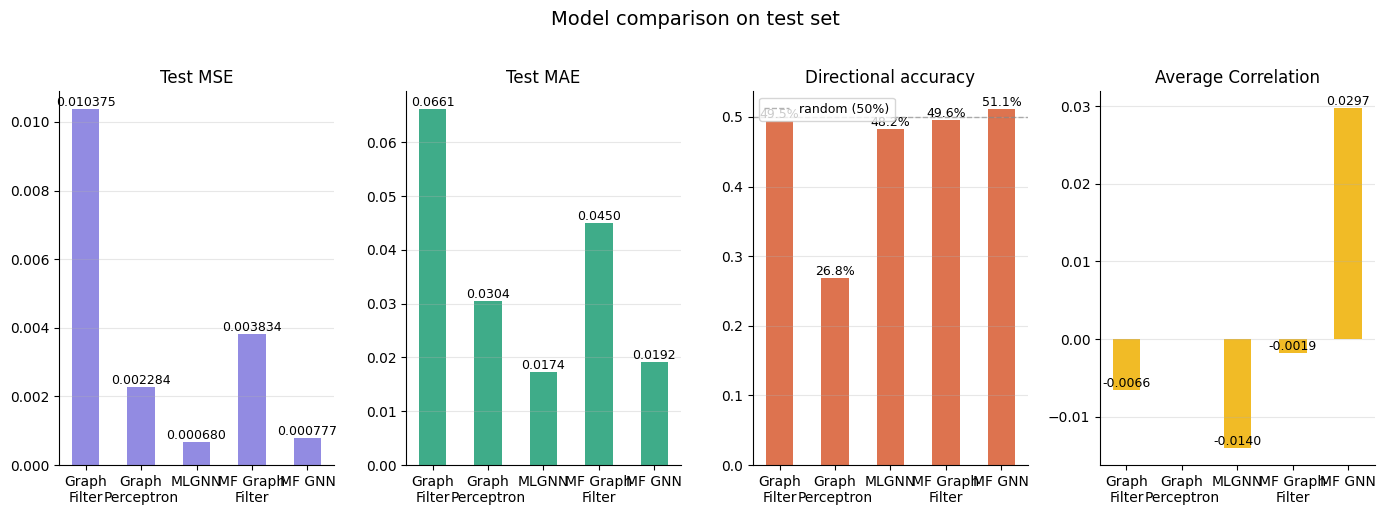

In [18]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Graph\nFilter', 'Graph\nPerceptron', 'MLGNN', 'MF Graph\nFilter', 'MF GNN']

x = np.arange(len(models))
w = 0.25
purple = '#7F77DD'
teal   = '#1D9E75'
coral  = '#D85A30'

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, vals, label, color, fmt in zip(
    axes,
    [summary['mse'], summary['mae'], summary['directional_accuracy'], summary['avg_correlation']],
    ['Test MSE', 'Test MAE', 'Directional accuracy', 'Average Correlation'],
    [purple, teal, coral, '#EFAF00'],
    ['.6f', '.4f', '.1%', '.4f']
):
    bars = ax.bar(x, vals, color=color, alpha=0.85, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                format(v, fmt), ha='center', va='bottom', fontsize=9)

# dashed line at 50% for directional accuracy
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='random (50%)')
axes[2].legend(fontsize=9)

plt.suptitle('Model comparison on test set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

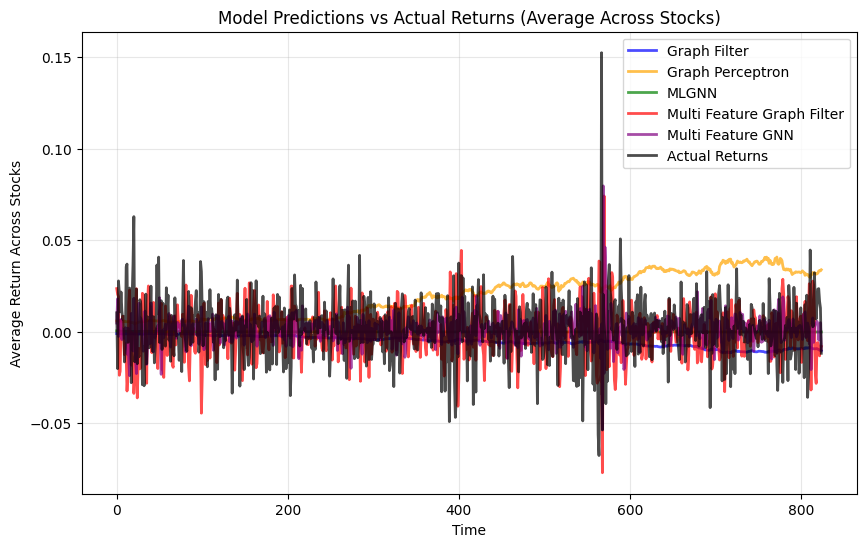

In [19]:
# Optional: plot deltas vs baseline
plt.figure(figsize=(10, 6))
plt.plot(gf_pred.mean(dim=1).numpy(), label='Graph Filter', linewidth=2, alpha=0.7, color='blue')
plt.plot(gp_pred.mean(dim= 1).numpy(), label='Graph Perceptron', linewidth=2, alpha=0.7, color='orange')
plt.plot(mlgnn_pred.mean(dim=1).numpy(), label='MLGNN', linewidth=2, alpha=0.7, color='green')
plt.plot(mfgf_pred.mean(dim=1).numpy(), label='Multi Feature Graph Filter', linewidth=2, alpha=0.7, color='red')
plt.plot(mfgnn_pred.mean(dim=1).numpy(), label='Multi Feature GNN', linewidth=2, alpha=0.7, color='purple')
plt.plot(y_test_tensor.mean(dim=1).numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color='black')
plt.xlabel('Time')
plt.ylabel('Average Return Across Stocks')
plt.title('Model Predictions vs Actual Returns (Average Across Stocks)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Multi-feature part

This part adds a multi-feature GNN model so that we can see the plan from the presentation: past 5 days, moving-average style features, and volatility. 

In [20]:
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std


In [21]:

# -----------------------------
# Multi-feature GNN model
# -----------------------------
class MultiFeatureGraphFilter(nn.Module):
    def __init__(self, gso, in_features, k, hidden_dim=16, activation=nn.ReLU()):
        super().__init__()
        self.gso = torch.tensor(gso, dtype=torch.float32) if not torch.is_tensor(gso) else gso.float()
        self.in_features = in_features
        self.k = k
        self.activation = activation

        # One k-hop filter per input feature
        self.filter_weights = nn.Parameter(torch.empty(in_features, k))
        nn.init.xavier_uniform_(self.filter_weights)

        # Mix features node-wise after graph filtering
        self.feature_mixer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            activation,
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        """
        x: (B, F, N)
        returns: (B, N)
        """
        B, F, N = x.shape
        outputs = []

        for f in range(F):
            xf = x[:, f, :]                          # (B,N)
            yf = filter_function(self.filter_weights[f], self.gso, xf)  # (B,N)
            outputs.append(yf.unsqueeze(1))         # (B,1,N)

        h = torch.cat(outputs, dim=1)               # (B,F,N)
        h = h.permute(0, 2, 1)                      # (B,N,F)
        y = self.feature_mixer(h).squeeze(-1)       # (B,N)
        return y


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    return {
        "mse": float(mse),
        "mae": float(mae),
        "directional_accuracy": float(directional_acc)
    }


def train_and_evaluate_multifeature_model(
    close_df,
    selected_features,
    split_date="2023-01-01",
    lag_days=5,
    ma_windows=(5, 10),
    vol_windows=(5,),
    lr=0.01,
    epochs=300,
    k=3,
    hidden_dim=16
):
    # Build full feature panel
    X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df = train_test_split_panel(
        close_df, split_date=split_date, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    # Select subset of features by name
    feature_idx = [feature_names.index(name) for name in selected_features]
    X_train = X_train[:, feature_idx, :]
    X_test = X_test[:, feature_idx, :]

    # Standardize
    X_train, X_test, _, _ = standardize_panel(X_train, X_test)

    # Graph built from train returns only
    train_returns_df = returns_df.loc[train_dates]
    corr = stock_graph(train_returns_df.dropna().values)
    corr = normalize_graph(corr)
    corr = torch.tensor(corr, dtype=torch.float32)

    # Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    # Model
    model = MultiFeatureGraphFilter(
        corr, in_features=len(selected_features), k=k, hidden_dim=hidden_dim, activation=nn.ReLU()
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, Y_train_tensor)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)

    metrics = evaluate_metrics(Y_test_tensor, test_pred)

    return {
        "model": model,
        "train_losses": train_losses,
        "test_pred": test_pred,
        "y_test": Y_test_tensor,
        "metrics": metrics,
        "selected_features": selected_features,
        "test_dates": test_dates
    }


In [22]:

# -----------------------------
# Feature sets to compare
# -----------------------------
all_close = yf.download(tickers, start="2018-01-01")["Close"].dropna()

feature_sets = {
    "baseline_ret_lag_1": ["ret_lag_1"],
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

results = {}
summary_rows = []

for name, feat_list in feature_sets.items():
    print(f"\nRunning: {name}")
    out = train_and_evaluate_multifeature_model(
        all_close,
        selected_features=feat_list,
        split_date="2023-01-01",
        lag_days=5,
        ma_windows=(5, 10),
        vol_windows=(5,),
        lr=0.01,
        epochs=300,
        k=3,
        hidden_dim=16
    )
    results[name] = out
    summary_rows.append({
        "feature_set": name,
        "num_features": len(feat_list),
        "mse": out["metrics"]["mse"],
        "mae": out["metrics"]["mae"],
        "directional_accuracy": out["metrics"]["directional_accuracy"]
    })

results_df = pd.DataFrame(summary_rows).sort_values("mse").reset_index(drop=True)
print("\n=== Multi-feature comparison ===")
print(results_df)


[*********************100%***********************]  10 of 10 completed



Running: baseline_ret_lag_1

Running: past_5_returns

Running: past_5_plus_ma

Running: past_5_plus_vol

Running: all_features

=== Multi-feature comparison ===
          feature_set  num_features       mse       mae  directional_accuracy
0  baseline_ret_lag_1             1  0.000683  0.017439              0.508000
1        all_features            10  0.000686  0.017652              0.503273
2      past_5_plus_ma             7  0.000691  0.017579              0.512485
3      past_5_returns             5  0.000692  0.017561              0.517697
4     past_5_plus_vol             6  0.000700  0.017746              0.501333


,feature_set,num_features,mse,mae,directional_accuracy
0,baseline_ret_lag_1,1,0.000683,0.017439,0.508000
1,all_features,10,0.000686,0.017652,0.503273
2,past_5_plus_ma,7,0.000691,0.017579,0.512485
3,past_5_returns,5,0.000692,0.017561,0.517697
4,past_5_plus_vol,6,0.000700,0.017746,0.501333


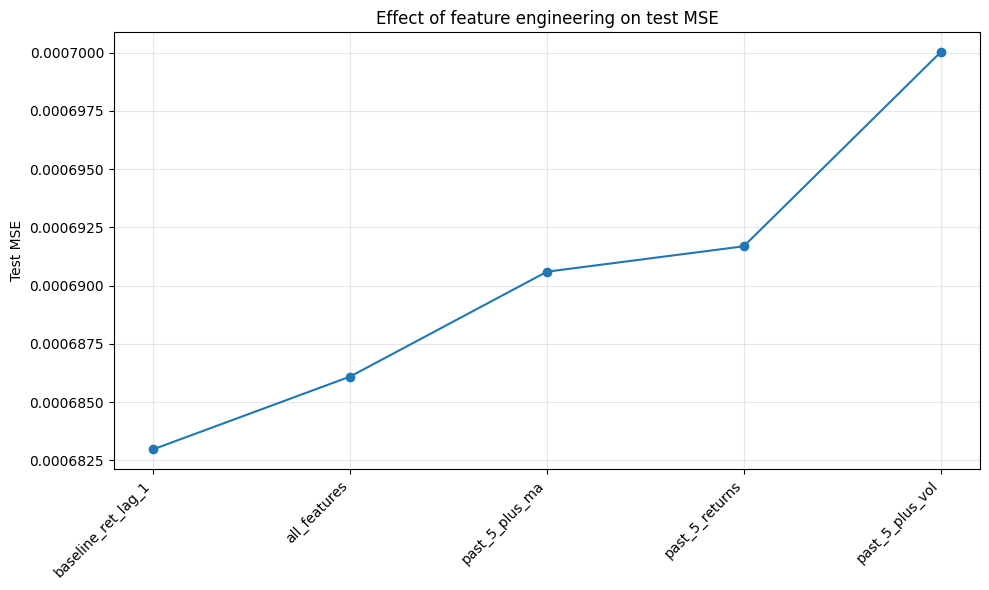

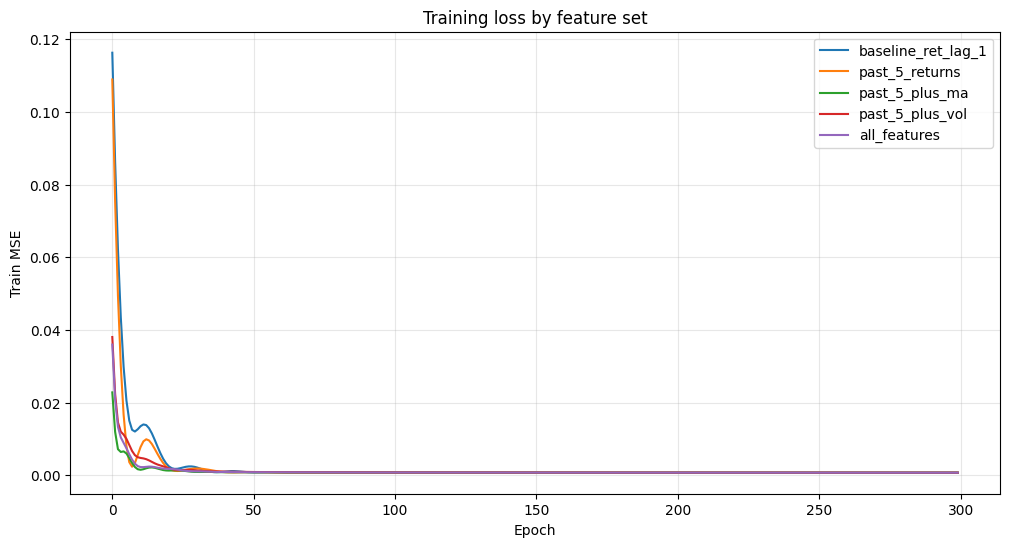

In [23]:

# Plot comparison table and training curves
display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(results_df["feature_set"], results_df["mse"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MSE")
plt.title("Effect of feature engineering on test MSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for name, out in results.items():
    plt.plot(out["train_losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss by feature set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best feature set: baseline_ret_lag_1
['ret_lag_1']
{'mse': 0.0006829725462011993, 'mae': 0.01743929833173752, 'directional_accuracy': 0.508}


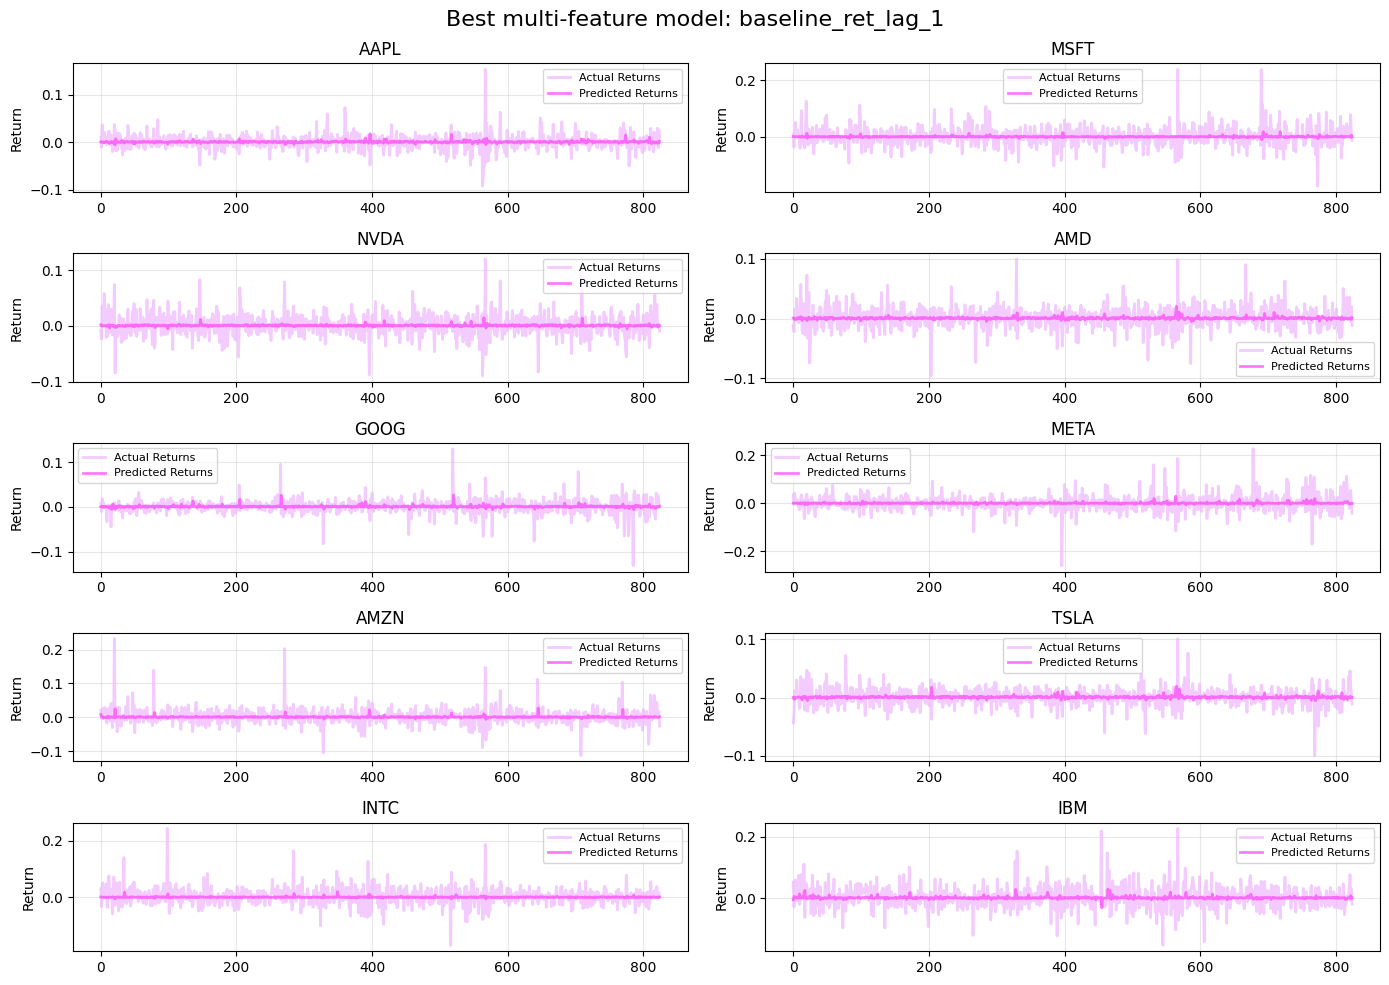

In [24]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

# Example: inspect best model predictions stock-by-stock
best_name = results_df.iloc[0]["feature_set"]
best_out = results[best_name]

print(f"Best feature set: {best_name}")
print(best_out["selected_features"])
print(best_out["metrics"])

plt.figure(figsize=(14, 10))
plt.suptitle(f"Best multi-feature model: {best_name}", fontsize=16)

best_pred = best_out["test_pred"].detach().cpu().numpy()
best_true = best_out["y_test"].detach().cpu().numpy()

for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i + 1)
    plt.plot(best_true[:, i], label="Actual Returns", linewidth=2, alpha=0.7, color=purple)
    plt.plot(best_pred[:, i], label="Predicted Returns", linewidth=2, alpha=0.7, color=pink)
    plt.title(ticker)
    plt.ylabel("Return")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [25]:

# Optional: direct deltas relative to the simplest baseline
baseline_mse = results["baseline_ret_lag_1"]["metrics"]["mse"]
baseline_mae = results["baseline_ret_lag_1"]["metrics"]["mae"]
baseline_dir = results["baseline_ret_lag_1"]["metrics"]["directional_accuracy"]

delta_df = results_df.copy()
delta_df["mse_change_vs_baseline"] = delta_df["mse"] - baseline_mse
delta_df["mae_change_vs_baseline"] = delta_df["mae"] - baseline_mae
delta_df["dir_acc_change_vs_baseline"] = delta_df["directional_accuracy"] - baseline_dir

print(delta_df.sort_values("mse_change_vs_baseline"))
display(delta_df.sort_values("mse_change_vs_baseline"))


          feature_set  num_features       mse       mae  directional_accuracy  \
0  baseline_ret_lag_1             1  0.000683  0.017439              0.508000   
1        all_features            10  0.000686  0.017652              0.503273   
2      past_5_plus_ma             7  0.000691  0.017579              0.512485   
3      past_5_returns             5  0.000692  0.017561              0.517697   
4     past_5_plus_vol             6  0.000700  0.017746              0.501333   

   mse_change_vs_baseline  mae_change_vs_baseline  dir_acc_change_vs_baseline  
0                0.000000                0.000000                    0.000000  
1                0.000003                0.000213                   -0.004727  
2                0.000008                0.000140                    0.004485  
3                0.000009                0.000121                    0.009697  
4                0.000017                0.000307                   -0.006667  


,feature_set,num_features,mse,mae,directional_accuracy,mse_change_vs_baseline,mae_change_vs_baseline,dir_acc_change_vs_baseline
0,baseline_ret_lag_1,1,0.000683,0.017439,0.508000,0.000000,0.000000,0.000000
1,all_features,10,0.000686,0.017652,0.503273,0.000003,0.000213,-0.004727
2,past_5_plus_ma,7,0.000691,0.017579,0.512485,0.000008,0.000140,0.004485
3,past_5_returns,5,0.000692,0.017561,0.517697,0.000009,0.000121,0.009697
4,past_5_plus_vol,6,0.000700,0.017746,0.501333,0.000017,0.000307,-0.006667
